# Problem 2.53: Second Derivative 1D Edge Detection on Images

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
The second derivative operation $y = \frac{d^2 x}{dt^2}$ is approximated by the difference equation:
$$
y[n] = x[n + 1] - 2x[n] + x[n - 1] \quad (2.124)
$$
which is a noncausal LTI system and is used as an edge detector in image processing.
* **(a)** Determine the impulse response of this edge detector.
* **(b)** Load the Lena image in MATLAB/Python and process it row-by-row using the above impulse response. Display the resulting image and comment on its appearance.
* **(c)** Now process the Lena image column-by-column using the impulse response in (a). Display the resulting image and comment on its appearance.

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


## (a) Impulse Response Determination

h[n] values: [ 1. -2.  1.]
h[n] time indices: [-1  0  1]


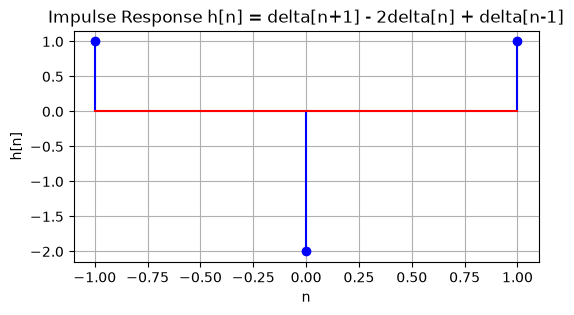

In [4]:
# 1D second derivative kernel
h = np.array([1.0, -2.0, 1.0])
n_h = np.array([-1, 0, 1])

print(f"h[n] values: {h}")
print(f"h[n] time indices: {n_h}")

plt.figure(figsize=(6, 3))
plt.stem(n_h, h, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title('Impulse Response h[n] = delta[n+1] - 2delta[n] + delta[n-1]')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid(True)
plt.show()


## (b) Row-by-Row Processing (Horizontal Second Derivative)

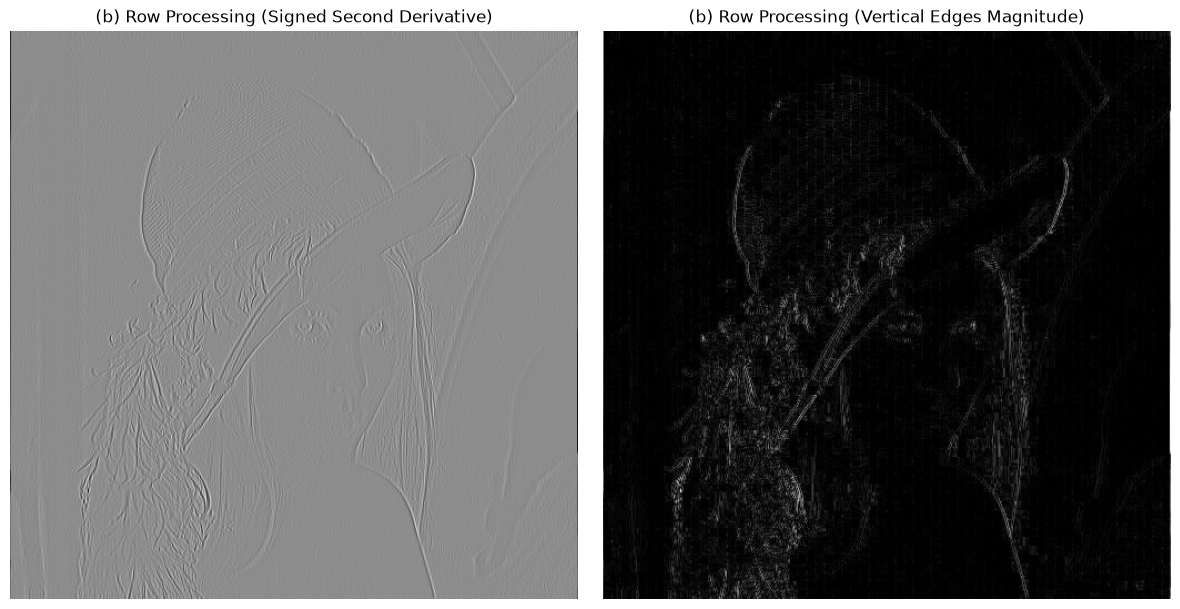

In [6]:
# Load Lena image
image_path = Path('lena.jpg')
if not image_path.exists():
    import urllib.request
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg"
    urllib.request.urlretrieve(url, image_path)

img = Image.open(image_path).convert('L')
x = np.array(img, dtype=np.float64)
nx, ny = x.shape

y_row = np.zeros_like(x)
for i in range(nx):
    # Convolve row with h[n] centered at origin (mode='same')
    y_row[i, :] = np.convolve(x[i, :], h, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(y_row, cmap='gray')
axes[0].set_title('(b) Row Processing (Signed Second Derivative)')
axes[0].axis('off')

axes[1].imshow(np.abs(y_row), cmap='gray')
axes[1].set_title('(b) Row Processing (Vertical Edges Magnitude)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## (c) Column-by-Column Processing (Vertical Second Derivative)

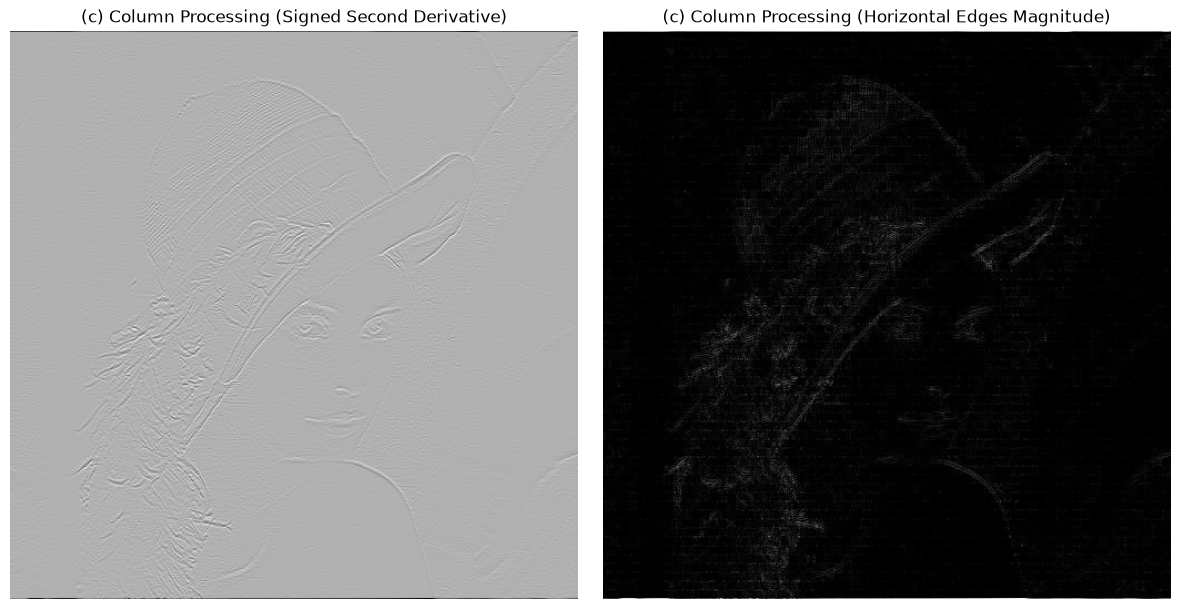

In [8]:
y_col = np.zeros_like(x)
for j in range(ny):
    # Convolve column with h[n]
    y_col[:, j] = np.convolve(x[:, j], h, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(y_col, cmap='gray')
axes[0].set_title('(c) Column Processing (Signed Second Derivative)')
axes[0].axis('off')

axes[1].imshow(np.abs(y_col), cmap='gray')
axes[1].set_title('(c) Column Processing (Horizontal Edges Magnitude)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Side-by-side Visual Comparison

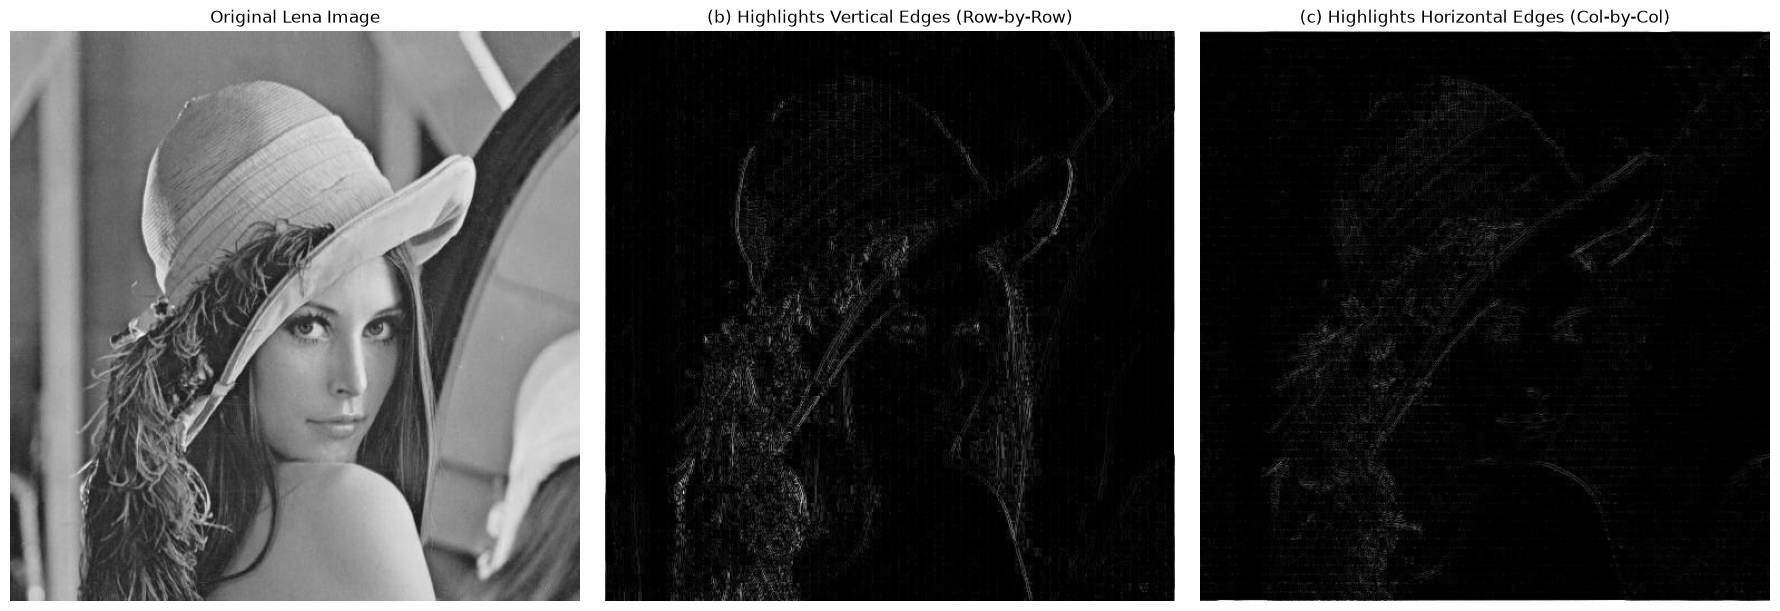

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(x, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Lena Image')
axes[0].axis('off')

axes[1].imshow(np.abs(y_row), cmap='gray')
axes[1].set_title('(b) Highlights Vertical Edges (Row-by-Row)')
axes[1].axis('off')

axes[2].imshow(np.abs(y_col), cmap='gray')
axes[2].set_title('(c) Highlights Horizontal Edges (Col-by-Col)')
axes[2].axis('off')

plt.tight_layout()
plt.show()
